In [1]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import scipy.linalg as la
%matplotlib widget


In [24]:
# returns GR_{i,j,t,t'}
def read_GR_hodlr(filename, name, t_max = -1, geometry_label = ""):
    f = h5.File(filename)
    nao = f[name + '/size1'][()]
    nt = f[name + '/nt'][()]
    nbox = f[name + '/nbox'][()]
    r2_dir = f['geometry/' + geometry_label + '/r2_dir'][()]
    blkc1 = f['geometry/' + geometry_label + '/blkc1'][()]
    blkc2 = f['geometry/' + geometry_label + '/blkc2'][()]
    blkr1 = f['geometry/' + geometry_label + '/blkr1'][()]
    blkr2 = f['geometry/' + geometry_label + '/blkr2'][()]

    # t_max=-1 means read everything
    if(t_max==-1 or t_max > nt): 
        t_max = nt
    
    # size of G is decided by t_max
    GR_h = np.zeros((nao, nao, t_max, t_max), dtype = complex)
    
    # read in triangle parts
    ret_dir = f[name + '/ret/dirtricol'][()]
    count = 0
    for tp in np.arange(t_max):
        for t in np.arange(r2_dir[tp]-tp+1):
            if tp+t < t_max: GR_h[:,:,tp+t,tp] = ret_dir[count,:,:]
            count+=1

    for b in np.arange(nbox):
        for i in np.arange(nao):
            for j in np.arange(nao):
                dim1_s = blkr1[b]
                dim1_e = min(blkr2[b]+1,t_max)
                dim2_s = blkc1[b]
                dim2_e = min(blkc2[b]+1,t_max)
                if(dim1_s<t_max and dim2_s<t_max):
                    label = name + '/ret/' + str(b) + '_' + str(i) + '_' + str(j)
                    U = f[label+'/U'][()]
                    S = f[label+'/S'][()]
                    V = f[label+'/V'][()]
                    # t  goes from first row of block to last row of block (or t_max)
                    # t' goes from first col to last col (or t_max)
                    GR_h[i,j,dim1_s:dim1_e,dim2_s:dim2_e] = np.dot(np.dot(U[:(dim1_e-dim1_s),:], np.diag(S)), np.matrix.getH(V[:(dim2_e-dim2_s),:]))
    return GR_h

# returns GL_{i,j,t,t'}
def read_GL_hodlr(filename, name, t_max = -1, geometry_label = ""):
    f = h5.File(filename)
    nao = f[name + '/size1'][()]
    nt = f[name + '/nt'][()]
    nbox = f[name + '/nbox'][()]
    ntri = f['geometry/' + geometry_label + '/ntri'][:]
    blkc1 = f['geometry/' + geometry_label + '/blkc1'][()]
    blkc2 = f['geometry/' + geometry_label + '/blkc2'][()]
    blkr1 = f['geometry/' + geometry_label + '/blkr1'][()]
    blkr2 = f['geometry/' + geometry_label + '/blkr2'][()]

    # t_max=-1 means read everything
    if(t_max==-1 or t_max > nt): 
        t_max = nt

    # size of G is decided by t_max
    GL_h = np.zeros((nao, nao, t_max, t_max), dtype = complex)

    # size of each diagonal square is given by maxima of ntri
    # last element is also a maximum
    sq_sizes = np.append(ntri[find_peaks(ntri)[0]], ntri[-1])

    # read in squares along diagonal.
    les_square = f[name + '/les/dir'][()]
    # i - index along les_square
    # s - index along diagonal, top left element of square
    i = 0
    s = 0
    for b in np.arange(nbox+1):
        e = s + sq_sizes[b]
        # block may be truncated by t_max, in which case we only need upper left portion
        e_block = min(e,t_max)
        # remember we are storing upper tri of GL - need to transpose result
        GL_h[:,:,s:e_block,s:e_block] = np.swapaxes(np.reshape(les_square[:,:,i:i+sq_sizes[b]**2],(nao,nao,sq_sizes[b],sq_sizes[b]))[:,:,:e_block-s,:e_block-s],-1,-2)
        i += sq_sizes[b]**2
        s += sq_sizes[b]
        if(s > t_max): break
    
    for b in np.arange(nbox):
        for i in np.arange(nao):
            for j in np.arange(nao):
                dim1_s = blkr1[b]
                dim1_e = min(blkr2[b]+1,t_max)
                dim2_s = blkc1[b]
                dim2_e = min(blkc2[b]+1,t_max)
                if(dim1_s<t_max and dim2_s<t_max):
                    label = name + '/les/' + str(b) + '_' + str(i) + '_' + str(j)
                    U = f[label+'/U'][()]
                    S = f[label+'/S'][()]
                    V = f[label+'/V'][()]
                    # remember we are storing upper tri part of GL - need to transpose result
                    # t (first time index) goes from first to last col
                    # t' (second time index) goes from first to last row
                    GL_h[i,j,dim2_s:dim2_e,dim1_s:dim1_e] = np.dot(np.dot(U[:(dim1_e-dim1_s),:], np.diag(S)), np.matrix.getH(V[:(dim2_e-dim2_s),:])).T
                    GL_h[j,i,dim1_s:dim1_e,dim2_s:dim2_e] = -GL_h[i,j,dim2_s:dim2_e,dim1_s:dim1_e].T.conj()
    return GL_h

def read_rho(filename, name):
    f = h5.File(filename)
    return f[name + "/data"][()][1:,:,:]

def compute_exact_GR(h_o, mu, h, tmax):
    """
    Computes the exact retarded Green's function G^R(t, t') on a 2D grid 
    for a time-invariant, potentially non-Hermitian Hamiltonian.
    
    Uses the exact analytical solution: G^R(t, t') = -i * exp(-i * (h_o - mu*I) * (t - t'))
    for t >= t', and 0 otherwise.
    """
    nao = h_o.shape[0]
    
    # Use round to prevent floating point truncation issues
    nt = int(round(tmax / h)) + 1
    
    # Initialize the output array with zeros
    G_R = np.zeros((nao, nao, nt, nt), dtype=complex)
    
    # Shift the Hamiltonian by the chemical potential
    # Standard NEGF convention: H_eff = h_o - mu * I
    # (Adjust the sign here if your specific convention is mu * I - h_o)
    h_eff = h_o - mu * np.eye(nao)
    
    # Compute the single time-step evolution operator for delta_t = h
    # U_step = exp(-i * h_eff * h)
    U_step = la.expm(-1j * h_eff * h)
    
    # Precompute U(delta_t) for all possible time differences k = (m - n)
    # where delta_t = k * h
    U_diff = np.zeros((nt, nao, nao), dtype=complex)
    U_diff[0] = np.eye(nao) # delta_t = 0
    
    for k in range(1, nt):
        # U(k * h) = U((k-1) * h) * U(h)
        U_diff[k] = U_diff[k-1] @ U_step
        
    # Populate the G^R grid
    # We only fill for t >= t' (which means m >= n)
    for m in range(nt):          # Index for t
        for n in range(m + 1):   # Index for t', restricted to n <= m
            
            # The time difference index is simply m - n
            k = m - n
            
            # Apply the exact solution: -i * U(t - t')
            G_R[:, :, m, n] = -1j * U_diff[k]
            
    return G_R

def compute_exact_rho(h_o, ellL, mu, h, tmax, rho0):
    """
    Computes the exact time evolution of the density matrix rho(t) 
    using row-major Liouville space vectorization.
    
    Output shape rearranged to: [nt, nao, nao] (Time index first)
    """
    nao = h_o.shape[0]
    n2 = nao * nao
    nt = int(round(tmax / h)) + 1
    
    # Initialize output array with time as the first index
    rho_t = np.zeros((nt, nao, nao), dtype=complex)
    
    # Shift Hamiltonian by chemical potential
    h_eff = h_o - mu * np.eye(nao)
    
    # 1. Build the row-major Liouvillian Superoperator A
    # A_row = -i * (h_eff (x) I - I (x) h_eff*)
    I = np.eye(nao)
    A_row = -1j * (np.kron(h_eff, I) - np.kron(I, np.conj(h_eff)))
    
    # Flatten the input matrices (NumPy defaults to row-major)
    rho_v = rho0.flatten()
    ellL_v = ellL.flatten()
    
    # 2. The Block Matrix Trick
    B = np.zeros((n2 + 1, n2 + 1), dtype=complex)
    B[:n2, :n2] = A_row
    B[:n2, n2] = 2 * ellL_v
    
    # Take the matrix exponential of B for a single time step 'h'
    expB = la.expm(B * h)
    
    U_step = expB[:n2, :n2]
    C_step = expB[:n2, n2]
    
    # 3. Time Evolution Loop
    # Record t=0, storing the reshaped matrix in the first time slice
    rho_t[0, :, :] = rho_v.reshape((nao, nao))
    
    for k in range(1, nt):
        # Step forward using the exact recurrence relation
        rho_v = U_step @ rho_v + C_step
        
        # Reshape back to nao x nao and store at time index k
        rho_t[k, :, :] = rho_v.reshape((nao, nao))
        
    return rho_t

def compute_exact_GL(h_o, mu, h, tmax, xi, rho_t):
    """
    Computes the exact lesser Green's function G^<(t, t') on a 2D grid 
    for a time-invariant, potentially non-Hermitian Hamiltonian in the region t' >= t.
    
    Parameters:
    - rho_t: The time-dependent density matrix shaped [nt, nao, nao]
    """
    nao = h_o.shape[0]
    nt = int(round(tmax / h)) + 1
    
    # Initialize the output array with zeros
    G_lesser = np.zeros((nao, nao, nt, nt), dtype=complex)
    
    # Shift the Hamiltonian by the chemical potential
    h_eff = h_o - mu * np.eye(nao)
    
    # Compute the single time-step ADJOINT evolution operator for delta_t = h
    # Notice the positive sign and the conjugate transpose
    U_adj_step = la.expm(1j * h_eff.conj().T * h)
    
    # Precompute U^\dagger(delta_t) for all possible time differences k = (t' - t)
    U_adj_diff = np.zeros((nt, nao, nao), dtype=complex)
    U_adj_diff[0] = np.eye(nao)
    
    for k in range(1, nt):
        # U^\dagger(k * h) = U^\dagger((k-1) * h) * U^\dagger(h)
        U_adj_diff[k] = U_adj_diff[k-1] @ U_adj_step
        
    # Populate the G^< grid
    # We only fill for t' >= t (which means n >= m)
    for m in range(nt):          # Index for t
        for n in range(m, nt):   # Index for t', restricted to n >= m
            
            # The time difference index is n - m
            k = n - m
            
            # Apply the exact solution: -i * xi * rho(t) * U^\dagger(t' - t)
            # Using matrix multiplication (@) for the spatial dimensions
            G_lesser[:, :, m, n] = -1j * xi * rho_t[m] @ U_adj_diff[k]
            if(m != n): G_lesser[:, :, n, m] = -G_lesser[:, :, m, n].T.conj()
            
    return G_lesser

In [45]:
inputfile = "/global/cfs/projectdirs/m5202/Thomas_nonint_diss_test/output_newlesstart.h5"

len_k = 5
len_h = 5
len_RV = 2
len_Lb = 2
len_Gb = 2

GR_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)
GL_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)
RHO_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)

RHO_0 = h5.File(inputfile)["rho0_mat"][()]
H = h5.File(inputfile)["H_mat"][()]
ellG = h5.File(inputfile)["ellG_mat"][()]
ellL = h5.File(inputfile)["ellL_mat"][()]

for k in range(len_k):
    for h in range(len_h):
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    k_val = k+1
                    h_val = 10*2**h
                    print(k_val,h_val,RV,Lb,Gb)
                    gr_4d_array = read_GR_hodlr(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/G", -1, str(h_val))
                    GR_list[k, h, RV, Lb, Gb] = gr_4d_array
                    gl_4d_array = read_GL_hodlr(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/G", -1, str(h_val))
                    GL_list[k, h, RV, Lb, Gb] = gl_4d_array
                    rho_3d_array = read_rho(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/rho")
                    RHO_list[k, h, RV, Lb, Gb] = rho_3d_array

1 10 0 0 0
1 10 0 0 1
1 10 0 1 0
1 10 0 1 1
1 10 1 0 0
1 10 1 0 1
1 10 1 1 0
1 10 1 1 1
1 20 0 0 0
1 20 0 0 1
1 20 0 1 0
1 20 0 1 1
1 20 1 0 0
1 20 1 0 1
1 20 1 1 0
1 20 1 1 1
1 40 0 0 0
1 40 0 0 1
1 40 0 1 0
1 40 0 1 1
1 40 1 0 0
1 40 1 0 1
1 40 1 1 0
1 40 1 1 1
1 80 0 0 0
1 80 0 0 1
1 80 0 1 0
1 80 0 1 1
1 80 1 0 0
1 80 1 0 1
1 80 1 1 0
1 80 1 1 1
1 160 0 0 0
1 160 0 0 1
1 160 0 1 0
1 160 0 1 1
1 160 1 0 0
1 160 1 0 1
1 160 1 1 0
1 160 1 1 1
2 10 0 0 0
2 10 0 0 1
2 10 0 1 0
2 10 0 1 1
2 10 1 0 0
2 10 1 0 1
2 10 1 1 0
2 10 1 1 1
2 20 0 0 0
2 20 0 0 1
2 20 0 1 0
2 20 0 1 1
2 20 1 0 0
2 20 1 0 1
2 20 1 1 0
2 20 1 1 1
2 40 0 0 0
2 40 0 0 1
2 40 0 1 0
2 40 0 1 1
2 40 1 0 0
2 40 1 0 1
2 40 1 1 0
2 40 1 1 1
2 80 0 0 0
2 80 0 0 1
2 80 0 1 0
2 80 0 1 1
2 80 1 0 0
2 80 1 0 1
2 80 1 1 0
2 80 1 1 1
2 160 0 0 0
2 160 0 0 1
2 160 0 1 0
2 160 0 1 1
2 160 1 0 0
2 160 1 0 1
2 160 1 1 0
2 160 1 1 1
3 10 0 0 0
3 10 0 0 1
3 10 0 1 0
3 10 0 1 1
3 10 1 0 0
3 10 1 0 1
3 10 1 1 0
3 10 1 1 1
3 20 0 0 0
3 20 

In [4]:
inputfile = "/global/cfs/projectdirs/m5202/Thomas_nonint_diss_test/output_LouiStartStep.h5"

len_k = 5
len_h = 5
len_RV = 2
len_Lb = 2
len_Gb = 2

GR_list_LouiStart = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)
GL_list_LouiStart = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)
RHO_list_LouiStart = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=object)

RHO_0 = h5.File(inputfile)["rho0_mat"][()]
H = h5.File(inputfile)["H_mat"][()]
ellG = h5.File(inputfile)["ellG_mat"][()]
ellL = h5.File(inputfile)["ellL_mat"][()]

for k in range(len_k):
    for h in range(len_h):
        k_val = k+1
        h_val = 10*2**h
        print(k_val,h_val,RV,Lb,Gb)
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    # gr_4d_array = read_GR_hodlr(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/G", -1, str(h_val))
                    # GR_list_LouiStart[k, h, RV, Lb, Gb] = gr_4d_array
                    # gl_4d_array = read_GL_hodlr(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/G", -1, str(h_val))
                    # GL_list_LouiStart[k, h, RV, Lb, Gb] = gl_4d_array
                    rho_3d_array = read_rho(inputfile, "/k" + str(k_val) + "_h" + str(h_val) + "_rv" + str(RV) + "_L" + str(Lb) + "_G" + str(Gb) + "/rho")
                    RHO_list_LouiStart[k, h, RV, Lb, Gb] = rho_3d_array

1 10 1 1 1
1 20 1 1 1
1 40 1 1 1
1 80 1 1 1
1 160 1 1 1
2 10 1 1 1
2 20 1 1 1
2 40 1 1 1
2 80 1 1 1
2 160 1 1 1
3 10 1 1 1
3 20 1 1 1
3 40 1 1 1
3 80 1 1 1
3 160 1 1 1
4 10 1 1 1
4 20 1 1 1
4 40 1 1 1
4 80 1 1 1
4 160 1 1 1
5 10 1 1 1
5 20 1 1 1
5 40 1 1 1
5 80 1 1 1
5 160 1 1 1


In [46]:
GR_exact_list = np.empty((len_h, len_Lb, len_Gb), dtype=object)
GR_err_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=float)

for h in range(len_h):
    for Lb in range(len_Lb):
        for Gb in range(len_Gb):
            h_val = 1./(10*2**h)
            GR_exact_list[h,Lb,Gb] = compute_exact_GR(H-1.j*(Gb*ellG+Lb*ellL), 0, h_val, 2)

for k in range(len_k):
    for h in range(len_h):
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    nt = GR_exact_list[h, Lb, Gb].shape[2]
                    GR_err_list[k, h, RV, Lb, Gb] = np.sum(np.abs(GR_list[k, h, RV, Lb, Gb]-GR_exact_list[h, Lb, Gb]))/(nt*(nt+1)/2.)
                    # GR_err_list[k, h, RV, Lb, Gb] = np.sum(np.abs(GR_list[k, h, RV, Lb, Gb][:,:,:,0]-GR_exact_list[h, Lb, Gb][:,:,:,0]))/nt
                    # GR_err_list[k, h, RV, Lb, Gb] = np.sum(np.abs(GR_list[k, h, RV, Lb, Gb][:,:,5:,5:]-GR_exact_list[h, Lb, Gb][:,:,5:,5:]))/(nt*(nt+1)/2.)

In [47]:
rho_exact_list = np.empty((len_h, len_Lb, len_Gb), dtype=object)
rho_err_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=float)

for h in range(len_h):
    for Lb in range(len_Lb):
        for Gb in range(len_Gb):
            h_val = 1./(10*2**h)
            rho_exact_list[h,Lb,Gb] = compute_exact_rho(H-1.j*(Gb*ellG+Lb*ellL), Lb*ellL, 0, h_val, 2, RHO_0)

for k in range(len_k):
    for h in range(len_h):
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    nt = rho_exact_list[h, Lb, Gb].shape[0]
                    rho_err_list[k, h, RV, Lb, Gb] = np.sum(np.abs(RHO_list[k, h, RV, Lb, Gb]-rho_exact_list[h, Lb, Gb]))/(nt)


In [48]:
rho_err_list_LouiStart = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=float)

for k in range(len_k):
    for h in range(len_h):
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    nt = rho_exact_list[h, Lb, Gb].shape[0]
                    rho_err_list_LouiStart[k, h, RV, Lb, Gb] = np.sum(np.abs(RHO_list_LouiStart[k, h, RV, Lb, Gb]-rho_exact_list[h, Lb, Gb]))/(nt)


In [49]:
GL_exact_list = np.empty((len_h, len_Lb, len_Gb), dtype=object)
GL_err_list = np.empty((len_k, len_h, len_RV, len_Lb, len_Gb), dtype=float)

for h in range(len_h):
    for Lb in range(len_Lb):
        for Gb in range(len_Gb):
            h_val = 1./(10*2**h)
            GL_exact_list[h,Lb,Gb] = compute_exact_GL(H-1.j*(Gb*ellG+Lb*ellL), 0, h_val, 2, -1, rho_exact_list[h,Lb,Gb])

for k in range(len_k):
    for h in range(len_h):
        for RV in range(len_RV):
            for Lb in range(len_Lb):
                for Gb in range(len_Gb):
                    nt = GL_exact_list[h, Lb, Gb].shape[2]
                    GL_err_list[k, h, RV, Lb, Gb] = (np.sum(np.abs(GL_list[k, h, RV, Lb, Gb]-GL_exact_list[h, Lb, Gb]))-rho_err_list[k, h, RV, Lb, Gb]*nt)/(nt*nt-nt)


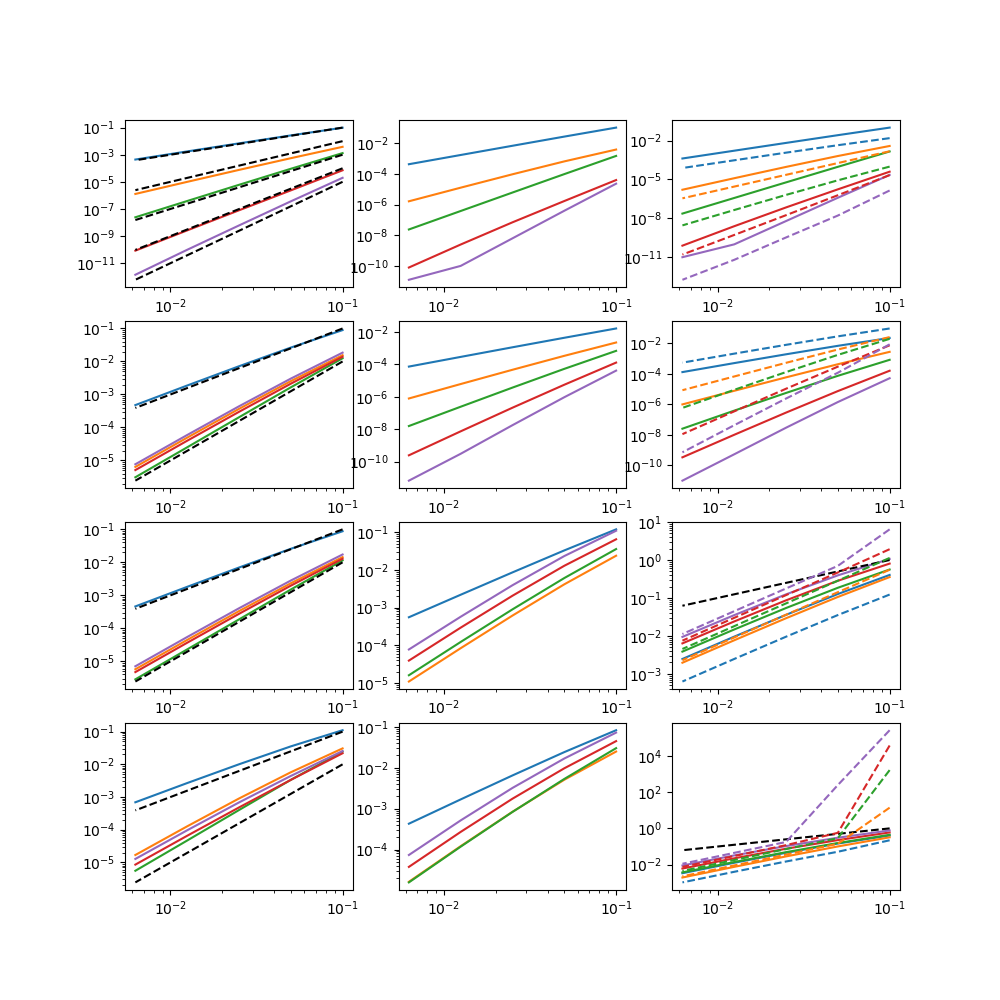

In [53]:
fig, axes = plt.subplots(4,3, figsize = (10,10))

hlist = 1./(10*2**np.arange(len_h))

#================================================================================
#                            Retarded
#================================================================================

axes[0,0].loglog(hlist, GR_err_list[0,:,0,0,0], color = "C0")
axes[0,0].loglog(hlist, GR_err_list[1,:,0,0,0], color = "C1")
axes[0,0].loglog(hlist, GR_err_list[2,:,0,0,0], color = "C2")
axes[0,0].loglog(hlist, GR_err_list[3,:,0,0,0], color = "C3")
axes[0,0].loglog(hlist, GR_err_list[4,:,0,0,0], color = "C4")

axes[0,0].loglog(hlist, 10*hlist**2, "--", color = "black")
axes[0,0].loglog(hlist, 10*hlist**3, "--", color = "black")
axes[0,0].loglog(hlist, 10*hlist**4, "--", color = "black")
axes[0,0].loglog(hlist, 10*hlist**5, "--", color = "black")
axes[0,0].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[1,0].loglog(hlist, GR_err_list[0,:,0,0,1], color = "C0")
axes[1,0].loglog(hlist, GR_err_list[1,:,0,0,1], color = "C1")
axes[1,0].loglog(hlist, GR_err_list[2,:,0,0,1], color = "C2")
axes[1,0].loglog(hlist, GR_err_list[3,:,0,0,1], color = "C3")
axes[1,0].loglog(hlist, GR_err_list[4,:,0,0,1], color = "C4")

axes[1,0].loglog(hlist, 10*hlist**2, "--", color = "black")
axes[1,0].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[1,0].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[1,0].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[1,0].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[2,0].loglog(hlist, GR_err_list[0,:,0,1,0], color = "C0")
axes[2,0].loglog(hlist, GR_err_list[1,:,0,1,0], color = "C1")
axes[2,0].loglog(hlist, GR_err_list[2,:,0,1,0], color = "C2")
axes[2,0].loglog(hlist, GR_err_list[3,:,0,1,0], color = "C3")
axes[2,0].loglog(hlist, GR_err_list[4,:,0,1,0], color = "C4")

axes[2,0].loglog(hlist, 10*hlist**2, "--", color = "black")
axes[2,0].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[2,0].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[2,0].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[2,0].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[3,0].loglog(hlist, GR_err_list[0,:,0,1,1], color = "C0")
axes[3,0].loglog(hlist, GR_err_list[1,:,0,1,1], color = "C1")
axes[3,0].loglog(hlist, GR_err_list[2,:,0,1,1], color = "C2")
axes[3,0].loglog(hlist, GR_err_list[3,:,0,1,1], color = "C3")
axes[3,0].loglog(hlist, GR_err_list[4,:,0,1,1], color = "C4")

axes[3,0].loglog(hlist, 10*hlist**2, "--", color = "black")
axes[3,0].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[3,0].loglog(hlist, 200*hlist**4, "--", color = "black")
# axes[3,0].loglog(hlist, 1000*hlist**5, "--", color = "black")
# axes[3,0].loglog(hlist, 5000*hlist**6, "--", color = "black")

#================================================================================
#                            density matrix
#================================================================================
rv = 0

axes[0,2].loglog(hlist, rho_err_list[0,:,rv,0,0], color = "C0")
axes[0,2].loglog(hlist, rho_err_list[1,:,rv,0,0], color = "C1")
axes[0,2].loglog(hlist, rho_err_list[2,:,rv,0,0], color = "C2")
axes[0,2].loglog(hlist, rho_err_list[3,:,rv,0,0], color = "C3")
axes[0,2].loglog(hlist, rho_err_list[4,:,rv,0,0], color = "C4")

# axes[0,2].loglog(hlist, 5*hlist**1, "--", color = "black")
# axes[0,2].loglog(hlist, 3*hlist**2, "--", color = "black")
# axes[0,2].loglog(hlist, 8*hlist**3, "--", color = "black")
# axes[0,2].loglog(hlist, 3*hlist**4, "--", color = "black")
# axes[0,2].loglog(hlist, 10*hlist**5, "--", color = "black")

axes[1,2].loglog(hlist, rho_err_list[0,:,rv,0,1], color = "C0")
axes[1,2].loglog(hlist, rho_err_list[1,:,rv,0,1], color = "C1")
axes[1,2].loglog(hlist, rho_err_list[2,:,rv,0,1], color = "C2")
axes[1,2].loglog(hlist, rho_err_list[3,:,rv,0,1], color = "C3")
axes[1,2].loglog(hlist, rho_err_list[4,:,rv,0,1], color = "C4")

# axes[1,2].loglog(hlist, 1.2*hlist**1, "--", color = "black")
# axes[1,2].loglog(hlist, 1.5*hlist**2, "--", color = "black")
# axes[1,2].loglog(hlist, 6*hlist**3, "--", color = "black")
# axes[1,2].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[1,2].loglog(hlist, 50*hlist**5, "--", color = "black")

axes[2,2].loglog(hlist, rho_err_list[0,:,rv,1,0], color = "C0")
axes[2,2].loglog(hlist, rho_err_list[1,:,rv,1,0], color = "C1")
axes[2,2].loglog(hlist, rho_err_list[2,:,rv,1,0], color = "C2")
axes[2,2].loglog(hlist, rho_err_list[3,:,rv,1,0], color = "C3")
axes[2,2].loglog(hlist, rho_err_list[4,:,rv,1,0], color = "C4")

axes[2,2].loglog(hlist, 10*hlist**1, "--", color = "black")
# axes[2,2].loglog(hlist, 3*hlist**2, "--", color = "black")
# axes[2,2].loglog(hlist, 8*hlist**3, "--", color = "black")
# axes[2,2].loglog(hlist, 8*hlist**4, "--", color = "black")
# axes[2,2].loglog(hlist, 30*hlist**5, "--", color = "black")

axes[3,2].loglog(hlist, rho_err_list[0,:,rv,1,1], color = "C0")
axes[3,2].loglog(hlist, rho_err_list[1,:,rv,1,1], color = "C1")
axes[3,2].loglog(hlist, rho_err_list[2,:,rv,1,1], color = "C2")
axes[3,2].loglog(hlist, rho_err_list[3,:,rv,1,1], color = "C3")
axes[3,2].loglog(hlist, rho_err_list[4,:,rv,1,1], color = "C4")

axes[3,2].loglog(hlist, 10*hlist**1, "--", color = "black")
# axes[3,2].loglog(hlist, 3*hlist**2, "--", color = "black")
# axes[3,2].loglog(hlist, 8*hlist**3, "--", color = "black")
# axes[3,2].loglog(hlist, 8*hlist**4, "--", color = "black")
# axes[3,2].loglog(hlist, 30*hlist**5, "--", color = "black")






rv = 1
axes[0,2].loglog(hlist, rho_err_list[0,:,rv,0,0], "--", color = "C0")
axes[0,2].loglog(hlist, rho_err_list[1,:,rv,0,0], "--", color = "C1")
axes[0,2].loglog(hlist, rho_err_list[2,:,rv,0,0], "--", color = "C2")
axes[0,2].loglog(hlist, rho_err_list[3,:,rv,0,0], "--", color = "C3")
axes[0,2].loglog(hlist, rho_err_list[4,:,rv,0,0], "--", color = "C4")

axes[1,2].loglog(hlist, rho_err_list[0,:,rv,0,1], "--", color = "C0")
axes[1,2].loglog(hlist, rho_err_list[1,:,rv,0,1], "--", color = "C1")
axes[1,2].loglog(hlist, rho_err_list[2,:,rv,0,1], "--", color = "C2")
axes[1,2].loglog(hlist, rho_err_list[3,:,rv,0,1], "--", color = "C3")
axes[1,2].loglog(hlist, rho_err_list[4,:,rv,0,1], "--", color = "C4")

axes[2,2].loglog(hlist, rho_err_list[0,:,rv,1,0], "--", color = "C0")
axes[2,2].loglog(hlist, rho_err_list[1,:,rv,1,0], "--", color = "C1")
axes[2,2].loglog(hlist, rho_err_list[2,:,rv,1,0], "--", color = "C2")
axes[2,2].loglog(hlist, rho_err_list[3,:,rv,1,0], "--", color = "C3")
axes[2,2].loglog(hlist, rho_err_list[4,:,rv,1,0], "--", color = "C4")

axes[3,2].loglog(hlist, rho_err_list[0,:,rv,1,1], "--", color = "C0")
axes[3,2].loglog(hlist, rho_err_list[1,:,rv,1,1], "--", color = "C1")
axes[3,2].loglog(hlist, rho_err_list[2,:,rv,1,1], "--", color = "C2")
axes[3,2].loglog(hlist, rho_err_list[3,:,rv,1,1], "--", color = "C3")
axes[3,2].loglog(hlist, rho_err_list[4,:,rv,1,1], "--", color = "C4")





# rv = 1
# axes[0,2].loglog(hlist, rho_err_list_LouiStart[0,:,rv,0,0], "-.", color = "C0")
# axes[0,2].loglog(hlist, rho_err_list_LouiStart[1,:,rv,0,0], "-.", color = "C1")
# axes[0,2].loglog(hlist, rho_err_list_LouiStart[2,:,rv,0,0], "-.", color = "C2")
# axes[0,2].loglog(hlist, rho_err_list_LouiStart[3,:,rv,0,0], "-.", color = "C3")
# axes[0,2].loglog(hlist, rho_err_list_LouiStart[4,:,rv,0,0], "-.", color = "C4")

# axes[1,2].loglog(hlist, rho_err_list_LouiStart[0,:,rv,0,1], "-.", color = "C0")
# axes[1,2].loglog(hlist, rho_err_list_LouiStart[1,:,rv,0,1], "-.", color = "C1")
# axes[1,2].loglog(hlist, rho_err_list_LouiStart[2,:,rv,0,1], "-.", color = "C2")
# axes[1,2].loglog(hlist, rho_err_list_LouiStart[3,:,rv,0,1], "-.", color = "C3")
# axes[1,2].loglog(hlist, rho_err_list_LouiStart[4,:,rv,0,1], "-.", color = "C4")

# axes[2,2].loglog(hlist, rho_err_list_LouiStart[0,:,rv,1,0], "-.", color = "C0")
# axes[2,2].loglog(hlist, rho_err_list_LouiStart[1,:,rv,1,0], "-.", color = "C1")
# axes[2,2].loglog(hlist, rho_err_list_LouiStart[2,:,rv,1,0], "-.", color = "C2")
# axes[2,2].loglog(hlist, rho_err_list_LouiStart[3,:,rv,1,0], "-.", color = "C3")
# axes[2,2].loglog(hlist, rho_err_list_LouiStart[4,:,rv,1,0], "-.", color = "C4")

# axes[3,2].loglog(hlist, rho_err_list_LouiStart[0,:,rv,1,1], "-.", color = "C0")
# axes[3,2].loglog(hlist, rho_err_list_LouiStart[1,:,rv,1,1], "-.", color = "C1")
# axes[3,2].loglog(hlist, rho_err_list_LouiStart[2,:,rv,1,1], "-.", color = "C2")
# axes[3,2].loglog(hlist, rho_err_list_LouiStart[3,:,rv,1,1], "-.", color = "C3")
# axes[3,2].loglog(hlist, rho_err_list_LouiStart[4,:,rv,1,1], "-.", color = "C4")


#================================================================================
#                            GL
#================================================================================

rv = 0
axes[0,1].loglog(hlist, GL_err_list[0,:,rv,0,0], color = "C0")
axes[0,1].loglog(hlist, GL_err_list[1,:,rv,0,0], color = "C1")
axes[0,1].loglog(hlist, GL_err_list[2,:,rv,0,0], color = "C2")
axes[0,1].loglog(hlist, GL_err_list[3,:,rv,0,0], color = "C3")
axes[0,1].loglog(hlist, GL_err_list[4,:,rv,0,0], color = "C4")

# axes[0,1].loglog(hlist, 10*hlist**2, "--", color = "black")
# axes[0,1].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[0,1].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[0,1].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[0,1].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[1,1].loglog(hlist, GL_err_list[0,:,rv,0,1], color = "C0")
axes[1,1].loglog(hlist, GL_err_list[1,:,rv,0,1], color = "C1")
axes[1,1].loglog(hlist, GL_err_list[2,:,rv,0,1], color = "C2")
axes[1,1].loglog(hlist, GL_err_list[3,:,rv,0,1], color = "C3")
axes[1,1].loglog(hlist, GL_err_list[4,:,rv,0,1], color = "C4")

# axes[1,1].loglog(hlist, 10*hlist**2, "--", color = "black")
# axes[1,1].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[1,1].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[1,1].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[1,1].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[2,1].loglog(hlist, GL_err_list[0,:,rv,1,0], color = "C0")
axes[2,1].loglog(hlist, GL_err_list[1,:,rv,1,0], color = "C1")
axes[2,1].loglog(hlist, GL_err_list[2,:,rv,1,0], color = "C2")
axes[2,1].loglog(hlist, GL_err_list[3,:,rv,1,0], color = "C3")
axes[2,1].loglog(hlist, GL_err_list[4,:,rv,1,0], color = "C4")

# axes[2,1].loglog(hlist, 10*hlist**2, "--", color = "black")
# axes[2,1].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[2,1].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[2,1].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[2,1].loglog(hlist, 10*hlist**6, "--", color = "black")

axes[3,1].loglog(hlist, GL_err_list[0,:,rv,1,1], color = "C0")
axes[3,1].loglog(hlist, GL_err_list[1,:,rv,1,1], color = "C1")
axes[3,1].loglog(hlist, GL_err_list[2,:,rv,1,1], color = "C2")
axes[3,1].loglog(hlist, GL_err_list[3,:,rv,1,1], color = "C3")
axes[3,1].loglog(hlist, GL_err_list[4,:,rv,1,1], color = "C4")

# axes[3,1].loglog(hlist, 10*hlist**2, "--", color = "black")
# axes[3,1].loglog(hlist, 10*hlist**3, "--", color = "black")
# axes[3,1].loglog(hlist, 10*hlist**4, "--", color = "black")
# axes[3,1].loglog(hlist, 10*hlist**5, "--", color = "black")
# axes[3,1].loglog(hlist, 10*hlist**6, "--", color = "black")


21


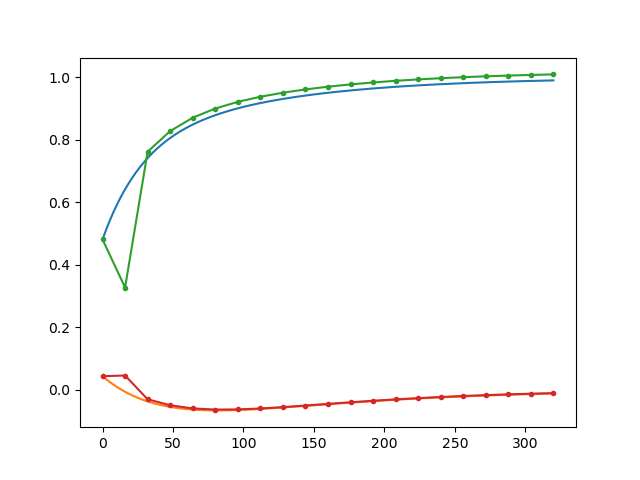

In [104]:
plt.figure()

Lb=1
Gb=0

plt.plot(rho_exact_list[4,Lb,Gb][:,0,0])
plt.plot(rho_exact_list[4,Lb,Gb][:,0,1])

k=0
h=0
rv=0
data = RHO_list[k,h,rv,Lb,Gb]
nt = data.shape[0]
print(nt)
plt.plot((2**(4-h))*np.arange(nt),data[:,0,0],".-")
plt.plot((2**(4-h))*np.arange(nt),data[:,0,1],".-")


In [ ]:
plt.figure()
Lb=1
Gb=1
h=1

for i in np.arange(2): plt.plot(GL_exact_list[h,Lb,Gb][0,3,i,:6])

k=4
rv=0
for i in np.arange(2): plt.plot(GL_list[k,h,rv,Lb,Gb][0,3,i,:6], "--")
